In [1]:
import py_ttcross as ttc
from py_ttcross.quantic_tt_cross.interpolators_1D import (
    greedy_one_dim_func_interpolator,
    ttrc_one_dim_func_interpolator,
)
import numpy as np
import matplotlib.pyplot as plt
from py_ttcross.pdes.operators import OneDimLaplacian
from py_ttcross.pdes.als import *

In [2]:
def target_func(x):
    return 2 * 0.3 + 6 * 0.1 * x - 12 * 0.6 * x ** 2 + 20 * 0.2 * x ** 3

def sol_func(x):
    return (0.3 * (x ** 2)) + (0.1 * (x ** 3)) - (0.6 * x ** 4) + (0.2 * x ** 5)

# def func(x):
#     return np.sin(3 * x)

# def exact_func(x):
#     return -np.sin(3 * x)/((3 )**2)


# 1. Encoding the target function in TT-Cross format

In [3]:
# interval = [-np.pi, np.pi]
interval = [0, 1]
d = 5

target_interpolator = greedy_one_dim_func_interpolator(
    func=target_func,
    interval=interval,
    d=d,
    complex_function=False,
    max_bond=10,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

target_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.0004220008850097656 seconds and 1 tries.
Sweep 1
Sweep 2
Sweep 3


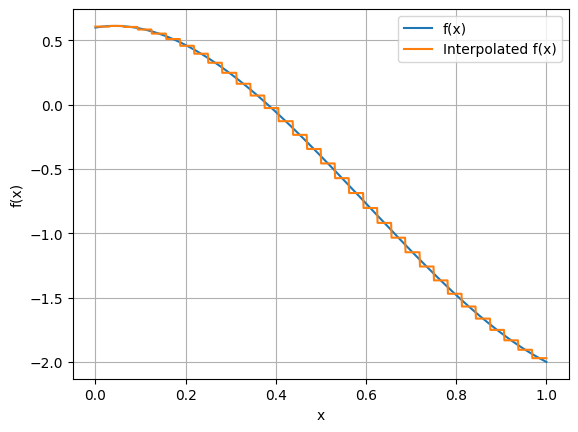

In [4]:
# We can check how the TT-Cross based algorithms obtain a good interpolation of the function

x = np.linspace(interval[0], interval[1], 1000)

true_target = [target_func(x_i) for x_i in x]

interpolation_target = np.array([target_interpolator.eval(x_i) for x_i in x])

plt.plot(x, true_target, label="f(x)")
plt.plot(x, interpolation_target, label="Interpolated f(x)")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 2. Optimizing according the PDE, starting from a random tensor train

In [5]:
laplacian = OneDimLaplacian(d, interval[1]- interval[0])

optimization_als = ALS(target_interpolator.mps, laplacian.laplacian,  4, 8, 1e-18, 3)

optimization_als.optimize()

(array([array([[-0.31521226, -0.9490212 ],
               [-0.9490212 ,  0.31521226]]),
        array([[[-1.99125027e-01,  1.98871612e-02, -3.40657844e-04,
                 -5.80617754e-05],
                [-1.71115125e-01, -3.80626528e-02, -3.14143994e-04,
                  4.96351980e-05]],
 
               [[ 4.50810121e-02,  1.14878563e-02, -2.15237501e-03,
                  1.27114849e-05],
                [-6.21184343e-02,  4.94369877e-02,  3.95326240e-04,
                  5.86181241e-05]]])                               ,
        array([[[-7.14423981e-01, -1.87092339e-02, -5.72940493e-05,
                  3.00023247e-07],
                [-6.98877524e-01,  2.86101914e-02, -1.26389079e-05,
                 -5.77846050e-06]],
 
               [[-6.00672514e-01,  2.57513332e-01,  1.00224144e-03,
                  6.58697245e-05],
                [ 6.24638841e-01,  4.27439534e-01, -4.08778855e-04,
                 -3.98466969e-05]],
 
               [[-9.09676582e-02,  7.30119782

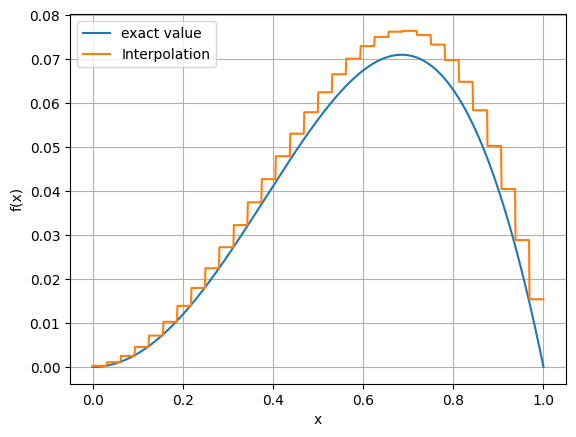

In [6]:
optimized_interpolator = greedy_one_dim_func_interpolator.load_mps(optimization_als.opt_mps, interval, complex_func=False)

x = np.linspace(interval[0], interval[1], 1000)

y = [sol_func(x_i) for x_i in x]

interpolation = np.array([optimized_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 3. Refining the grid

In [7]:
prolong_als = ProlongationALS(optimization_als.opt_mps, 10, 12, 1e-10, 5)

prolong_als.optimize()

(array([array([[-0.32514292-1.79718675e-80j,  0.94566489+2.52339479e-80j],
               [-0.94566489-3.32795896e-64j, -0.32514292-1.14423439e-64j]]),
        array([[[-2.83062224e-01+3.98039145e-82j,
                  2.76240275e-02+4.30456322e-81j,
                  5.32899860e-04+2.28912869e-83j,
                 -9.22937884e-05-4.81858057e-84j],
                [-2.36110134e-01-1.58716566e-65j,
                 -5.67371027e-02+1.17902536e-65j,
                  4.16317152e-04-3.17947368e-67j,
                  8.08568573e-05+1.23003813e-68j]],
 
               [[-6.46086873e-02+1.11038726e-65j,
                 -1.77649262e-02-6.68281677e-66j,
                 -2.98254870e-03+9.20917686e-67j,
                 -2.40847318e-05+2.62293737e-69j],
                [ 9.27877784e-02+5.35897397e-65j,
                 -7.24734973e-02-8.92955085e-66j,
                  6.08290903e-04-2.44629688e-67j,
                 -9.25751721e-05-3.70537617e-68j]]]),
        array([[[-7.15807467e-01+2.429

/Users/pau_qili/miniconda3/envs/py_ttcross/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pau_qili/miniconda3/envs/py_ttcross/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


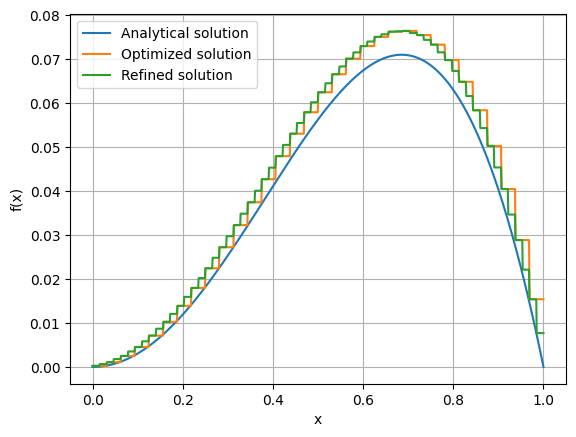

In [8]:
prolongated_interpolator = greedy_one_dim_func_interpolator.load_mps(prolong_als.fine_mps, interval, complex_func=False)

x = np.linspace(interval[0], interval[1], 1000)

true_solution = [sol_func(x_i) for x_i in x]

optimized_solution = np.array([optimized_interpolator.eval(x_i) for x_i in x])

refined_solution = np.array([prolongated_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="Analytical solution")
plt.plot(x, optimized_solution, label="Optimized solution")
plt.plot(x, refined_solution, label="Refined solution")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 4. Re-optimizing the solution

In [9]:
refined_target_interpolator = greedy_one_dim_func_interpolator(
    func=target_func,
    interval=interval,
    d=d + 1,
    complex_function=False,
    max_bond=10,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

refined_target_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.0007066726684570312 seconds and 1 tries.
Sweep 1
Sweep 2
Sweep 3


In [10]:
refined_laplacian = OneDimLaplacian(d + 1, interval[1]- interval[0])

reoptimization_als = ALS(refined_target_interpolator.mps, refined_laplacian.laplacian,  4, 8, 1e-18, 3, prolong_als.fine_mps)

reoptimization_als.optimize()

(array([array([[-0.30856252-9.64738755e-96j,  0.95120406-2.23009134e-95j],
               [-0.95120406-6.72659951e-80j, -0.30856252-2.18205179e-80j]]),
        array([[[-2.71751919e-01+4.68011305e-98j,
                  2.73778518e-02+6.69633595e-97j,
                  5.20334346e-04+4.84126458e-98j,
                 -9.33127942e-05-4.95595433e-99j],
                [-2.26234022e-01-5.58911048e-81j,
                 -5.56977122e-02-1.56253361e-81j,
                  4.45446809e-04-4.85466262e-83j,
                  8.02852392e-05+1.07015230e-84j]],
 
               [[-6.06119764e-02-1.72817467e-81j,
                 -1.57073380e-02-2.98758015e-82j,
                 -3.17422439e-03+1.41134519e-82j,
                 -2.12021307e-05+2.47625919e-84j],
                [ 8.80013294e-02+4.94091501e-81j,
                 -6.94624334e-02-4.27685432e-81j,
                  5.65685391e-04+3.82097620e-83j,
                 -9.63596960e-05-5.63618001e-84j]]]),
        array([[[-7.16106013e-01+8.851

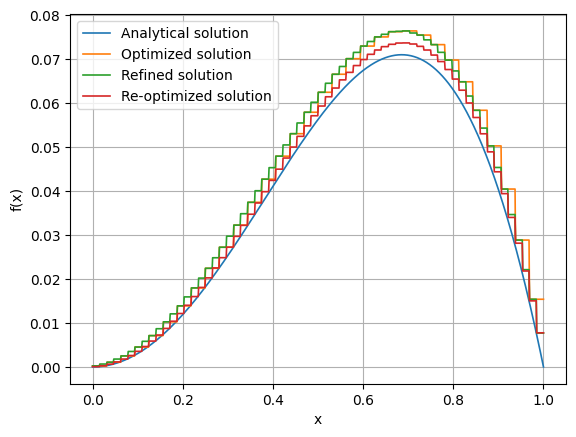

In [11]:
reoptimized_interpolator = greedy_one_dim_func_interpolator.load_mps(reoptimization_als.opt_mps, interval, complex_func=False)

x = np.linspace(interval[0], interval[1], 1000)

true_solution = [sol_func(x_i) for x_i in x]

optimized_solution = np.array([optimized_interpolator.eval(x_i) for x_i in x])
refined_solution = np.array([prolongated_interpolator.eval(x_i) for x_i in x])
reoptimized_solution = np.array([reoptimized_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="Analytical solution", linewidth=1.2)
plt.plot(x, optimized_solution, label="Optimized solution", linewidth=1.2)
plt.plot(x, refined_solution, label="Refined solution", linewidth=1.2)
plt.plot(x, reoptimized_solution, label="Re-optimized solution", linewidth=1.2)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.savefig("comparison.jpg", dpi=300)
plt.show()